In [75]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI

In [76]:
token = os.getenv("GITHUB_TOKEN")
endpoint = "https://models.github.ai/inference"
model = "openai/gpt-4.1-mini"

In [77]:
llm = ChatOpenAI(
    model=model,
    api_key=token,
    base_url=endpoint
)

In [78]:
from langgraph.types import Command

In [79]:
from langgraph.prebuilt import create_react_agent

In [80]:
def add_number(state):
    result = state["num1"]+state["num2"]
    print(f"addition is {result}")
    return Command(goto="multiply", update={"sum":result})

In [81]:
state = {"num1":10, "num2":20}

In [82]:
add_number(state)

addition is 30


Command(update={'sum': 30}, goto='multiply')

Creating one dummy multiagent

In [83]:
from typing import Annotated,Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

In [84]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    name:str
    age: int
    DOB: int

In [85]:
def transfer_to_multiplication_expert():
    "Ask multiplicatin agent for a help"
    return

In [86]:
def transfer_to_additon_expert():
    "Ask addition agent for a help"
    return

In [87]:
llm_with_tools = llm.bind_tools([transfer_to_multiplication_expert])

In [88]:
response = llm_with_tools.invoke("hi")

In [89]:
response.content

'Hello! How can I assist you today?'

In [90]:
response.tool_calls

[]

In [91]:
response = llm_with_tools.invoke("what is 2 multiply by 2")

In [92]:
response.tool_calls

[{'name': 'transfer_to_multiplication_expert',
  'args': {},
  'id': 'call_l0DWBzoosxpP6FDJBW88e4kT',
  'type': 'tool_call'}]

In [93]:
from typing_extensions import Literal
from langgraph.graph import MessagesState, StateGraph, START, END

In [94]:
system_prompt = (
        "you are an addition expert , you can ask the multiplication expert for help with multiplicaiton"
        "always to you portion of a calculation before handoff"
    )
  

In [95]:
messages = [{"role":"system", "content":system_prompt}]+ ["Can you tell me addtion of 2 and 2"]

In [96]:
messages

[{'role': 'system',
  'content': 'you are an addition expert , you can ask the multiplication expert for help with multiplicaitonalways to you portion of a calculation before handoff'},
 'Can you tell me addtion of 2 and 2']

In [97]:
def additional_expert(state:MessagesState)-> Command[Literal["additional_expert","__end__"]]:
    system_prompt = (
        "you are an addition expert , you can ask the multiplication expert for help with multiplicaiton"
        "always to you portion of a calculation before handoff"
    )
    messages = [{"role":"system", "content":system_prompt}]+ state["messages"]

    llm_with_tools= llm.bind_tools({transfer_to_multiplication_expert})
    ai_message= llm_with_tools.invoke(messages)

    if len(ai_message.tool_calls)>0:
        tool_call_id = ai_message.tool_calls[-1]["id"]
        tool_message={
            "role":"tool",
            "content":"Successfully transferred",
            "tool_call_id":tool_call_id,
        }

        return Command(
            goto="multiplication_expert",update={"messages":[ai_message,tool_message]}
        )
    return {"messages":[ai_message]}

In [98]:
def multiplication_expert(state:MessagesState)-> Command[Literal["multiplication_expert","__end__"]]:
    system_prompt = (
        "you are an multiplication expert , you can ask the multiplication expert for help with multiplicaiton"
        "always to you portion of a calculation before handoff"
    )
    messages = [{"role":"system", "content":system_prompt}]+ state["messages"]

    llm_with_tools= llm.bind_tools({transfer_to_multiplication_expert})
    ai_message= llm_with_tools.invoke(messages)

    if len(ai_message.tool_calls)>0:
        tool_call_id = ai_message.tool_calls[-1]["id"]
        tool_message={
            "role":"tool",
            "content":"Successfully transferred",
            "tool_call_id":tool_call_id,
        }

        return Command(
            goto="additional_expert",update={"messages":[ai_message,tool_message]}
        )
    return {"messages":[ai_message]}

In [99]:
graph= StateGraph(MessagesState)

In [100]:
graph.add_node("additional_expert", additional_expert)

In [101]:
graph.add_node("multiplication_expert", multiplication_expert)

In [109]:
graph.add_edge(START,"additional_expert")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


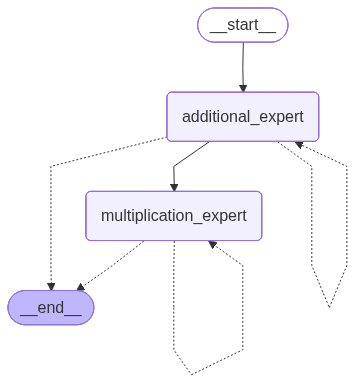

In [110]:
graph.compile()